## Setup

In [1]:
import torch
print(torch.cuda.is_available())        # True
print(torch.cuda.get_device_name(0))    # Tesla T4

True
Tesla T4


In [41]:
import os
import shutil

# Remove the directory if it already exists
if os.path.exists('/content/road_damage_detection'):
    shutil.rmtree('/content/road_damage_detection')
    os.chdir('/content')

!git clone 'https://github.com/ksk-17/road_damage_detection.git'

Cloning into 'road_damage_detection'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 97 (delta 56), reused 68 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 65.65 KiB | 4.38 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
from google.colab import files
files.upload()   # select kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ksk872","key":"ced87b2138f4c1ac99ed33fecd70a5ce"}'}

In [24]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

## Download the dataset

In [6]:
import kagglehub
path = kagglehub.dataset_download("aliabdelmenam/rdd-2022")
print("Downloaded to:", path)

100%|██████████| 9.90G/9.90G [01:42<00:00, 104MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1


In [7]:
import os
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'val' in dirs:
        data_dir = root
        print("Data dir:", data_dir)
        break

Data dir: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT


In [8]:
DATA_DIR = data_dir

In [9]:
os.listdir(DATA_DIR)

['train', 'val', 'test']

In [10]:
CKPT_DIR = "/content/drive/Shareddrives/CMPE_258/training_checkpoints"
os.listdir(CKPT_DIR)

['rtdetrv2_improved',
 'yolov11_improved',
 'rtdetrv2_baseline',
 'yolov11_baseline']

## Install Dependencies

In [11]:
!pip install ultralytics albumentations rich PyYAML opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.8 MB/s eta 0:00:00


In [42]:
import os
os.chdir('/content/road_damage_detection')

## Run models

In [ ]:
# YOLOv11 baseline
!python train.py --config yolov11_base-line.yaml --data-dir $DATA_DIR --checkpoint-dir $CKPT_DIR --imgsz 512

In [ ]:
# RT-DETRv2 baseline
!python train.py --config rtdetr_baseline.yaml --data-dir $DATA_DIR --checkpoint-dir $CKPT_DIR --imgsz 512

In [ ]:
# YOLOv11 with all improvements
!python train.py --config yolov11_improved.yaml --data-dir $DATA_DIR --checkpoint-dir $CKPT_DIR --imgsz 512

In [ ]:
# RT-DETRv2 with improvements
!python train.py --config rtdetr_improved.yaml --data-dir $DATA_DIR --checkpoint-dir $CKPT_DIR --imgsz 512

## Ablation Study

In [43]:
!python ablation.py --config ablation.yaml --checkpoint-dir $CKPT_DIR --data-dir $DATA_DIR --device cuda

╭──────────────────────────────────────────────────────────────────────────────╮
│ Ablation Study — 4 model(s)                                                  │
│ Checkpoints : /content/drive/Shareddrives/CMPE_258/training_checkpoints      │
│ Data        :                                                                │
│ /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT  │
│ Output      : runs/ablation                                                  │
╰──────────────────────────────────────────────────────────────────────────────╯
History: yolov11_baseline — 50 epochs
History: yolov11_improved — 50 epochs
History: rtdetrv2_baseline — 50 epochs
History: rtdetrv2_improved — 56 epochs

Evaluating models on val set...
[YOLOv11] Loaded yolo11m | FPN scales: 3 | Classes: 5
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅

## Display plots inline


── metrics_comparison.png ──


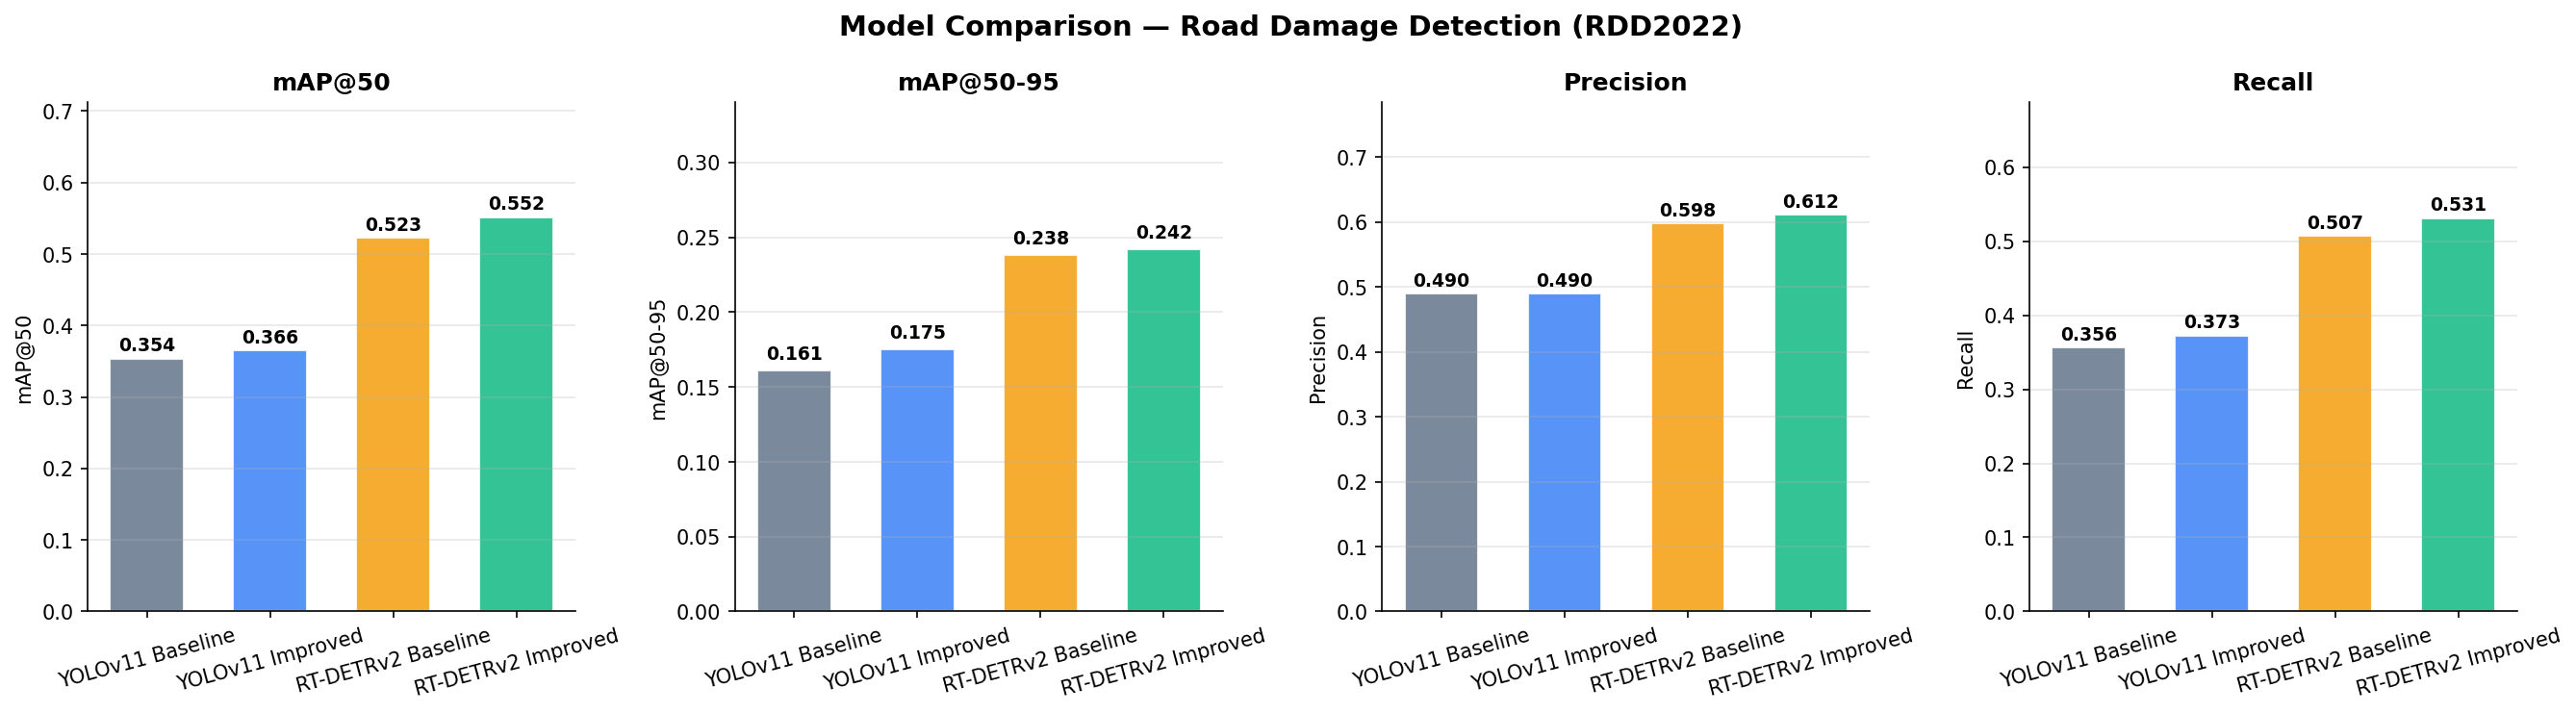


── loss_curves.png ──


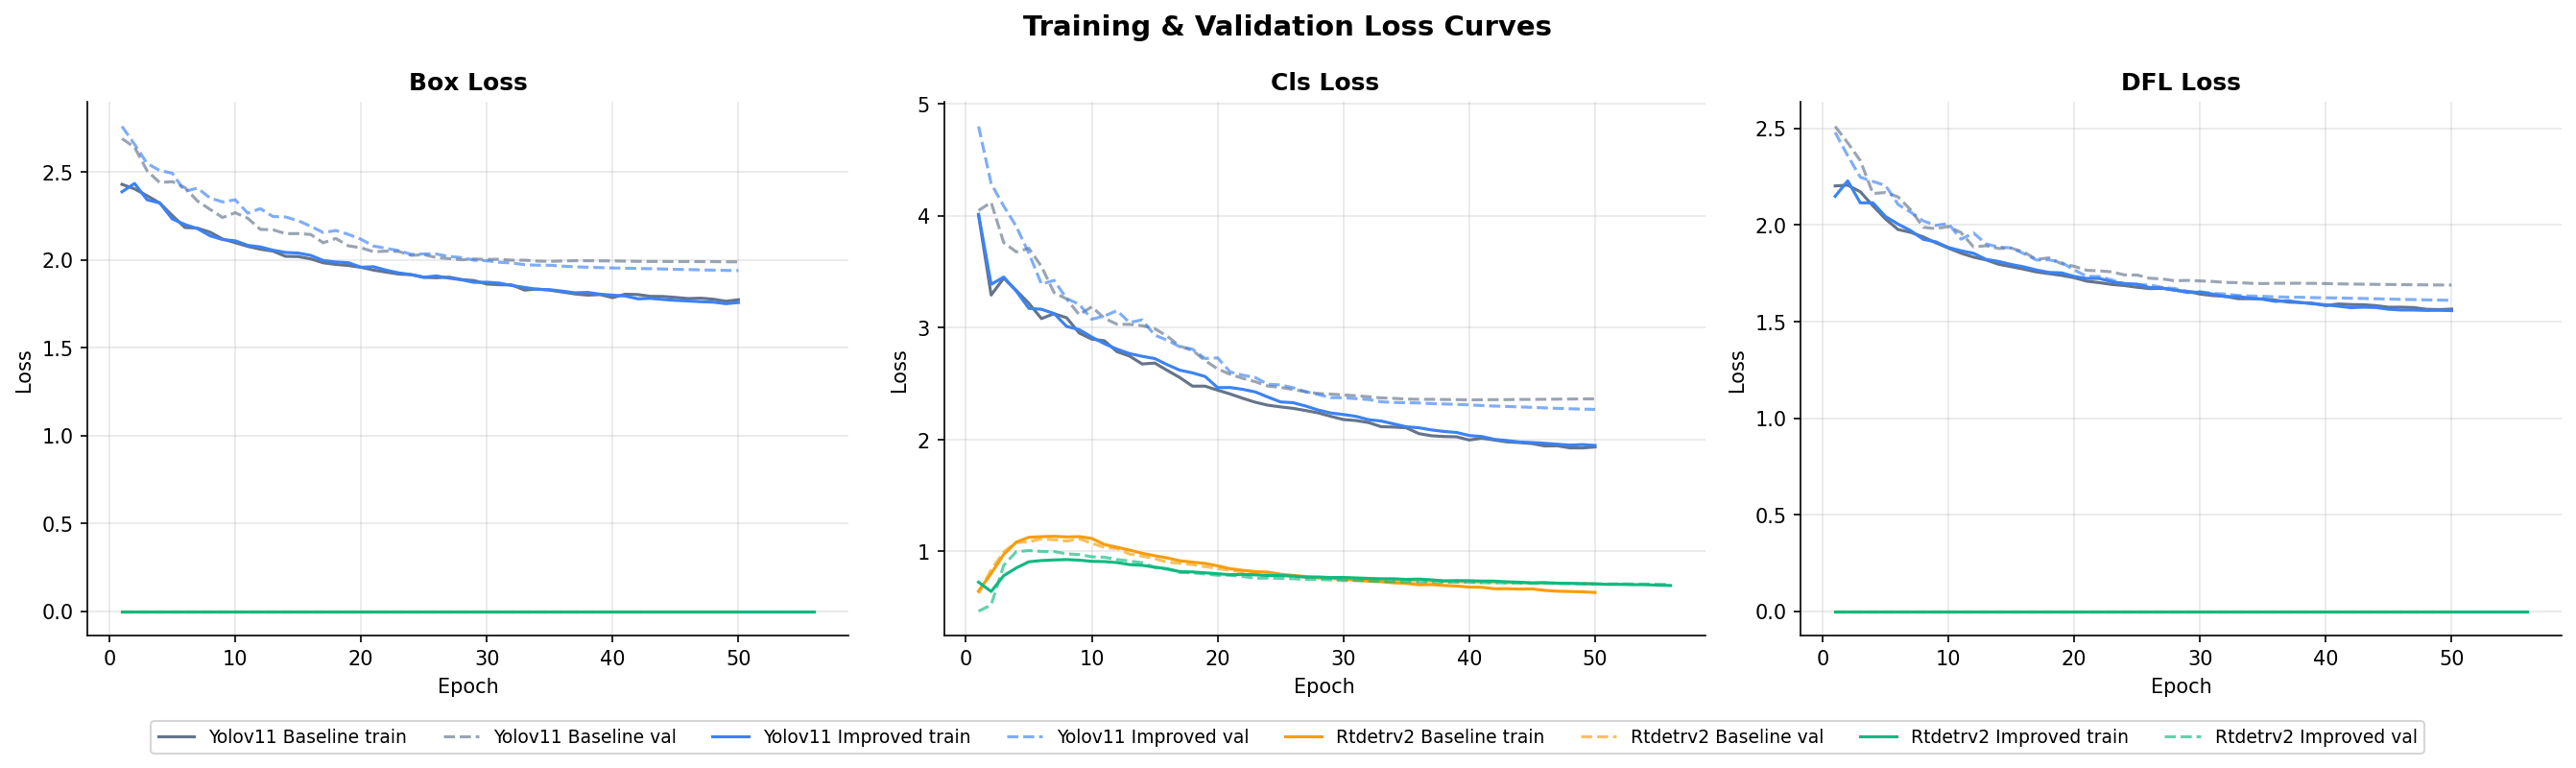


── metric_curves.png ──


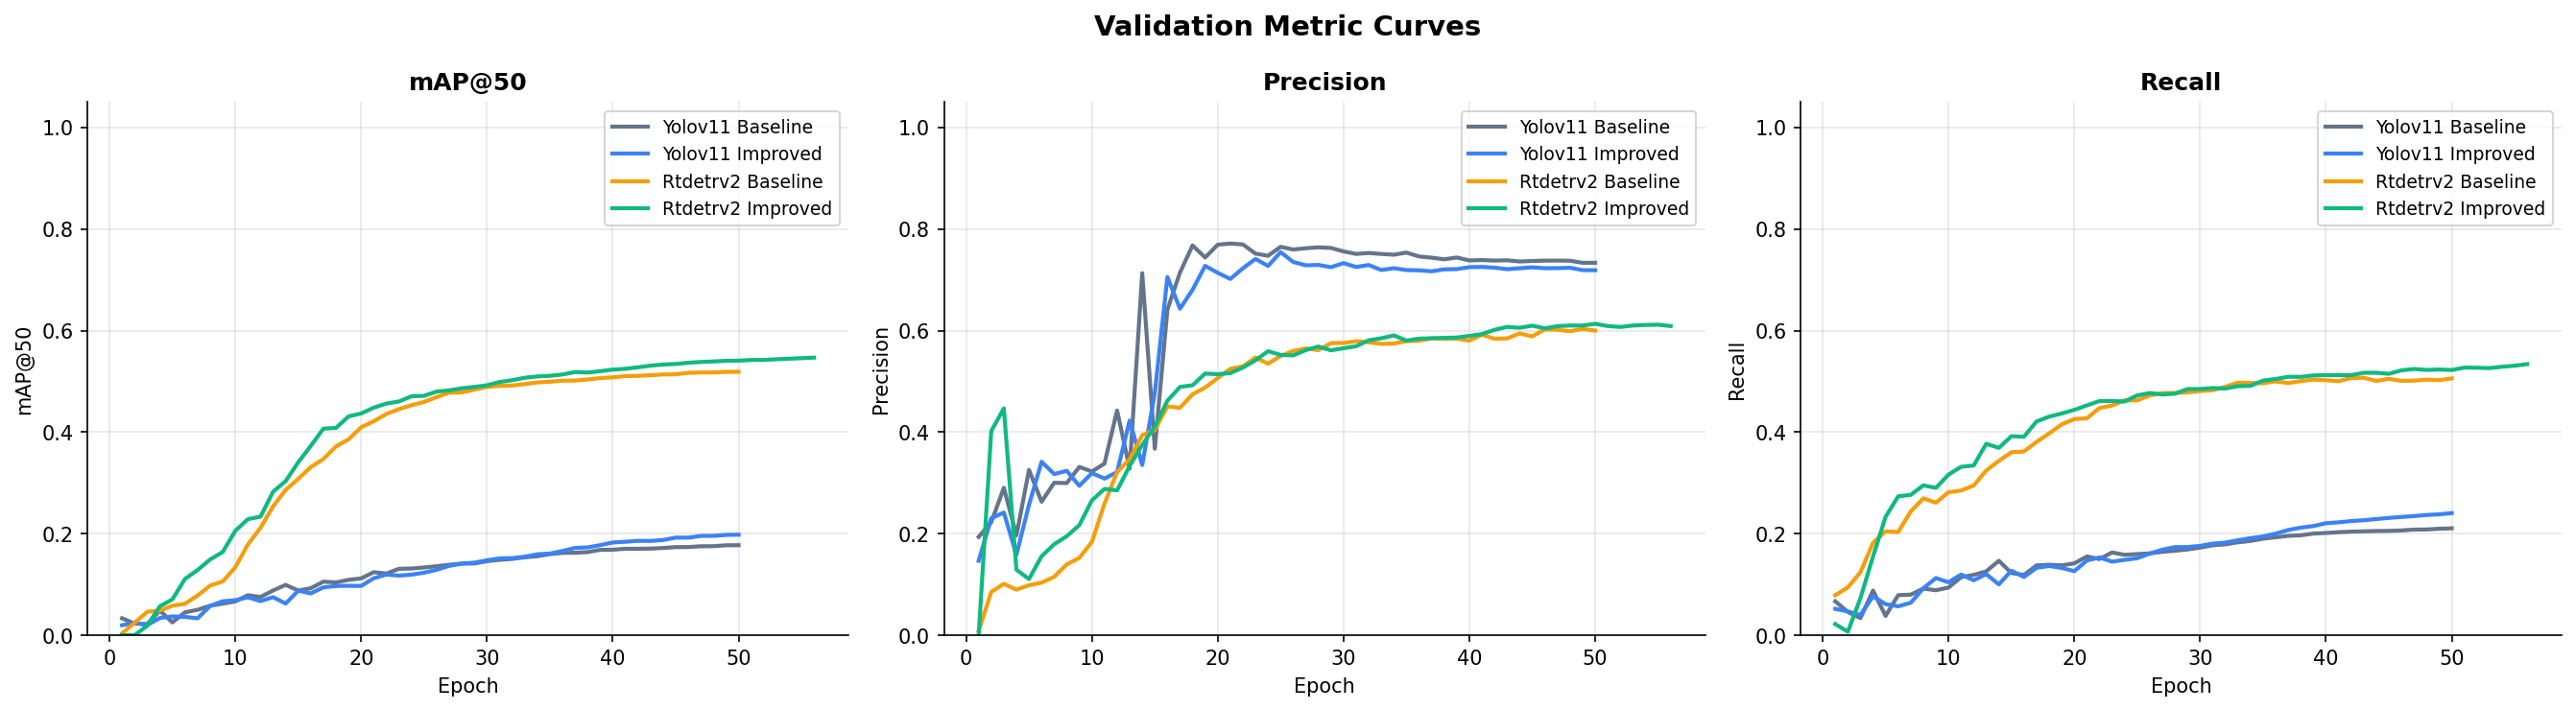


── per_class_mAP.png ──


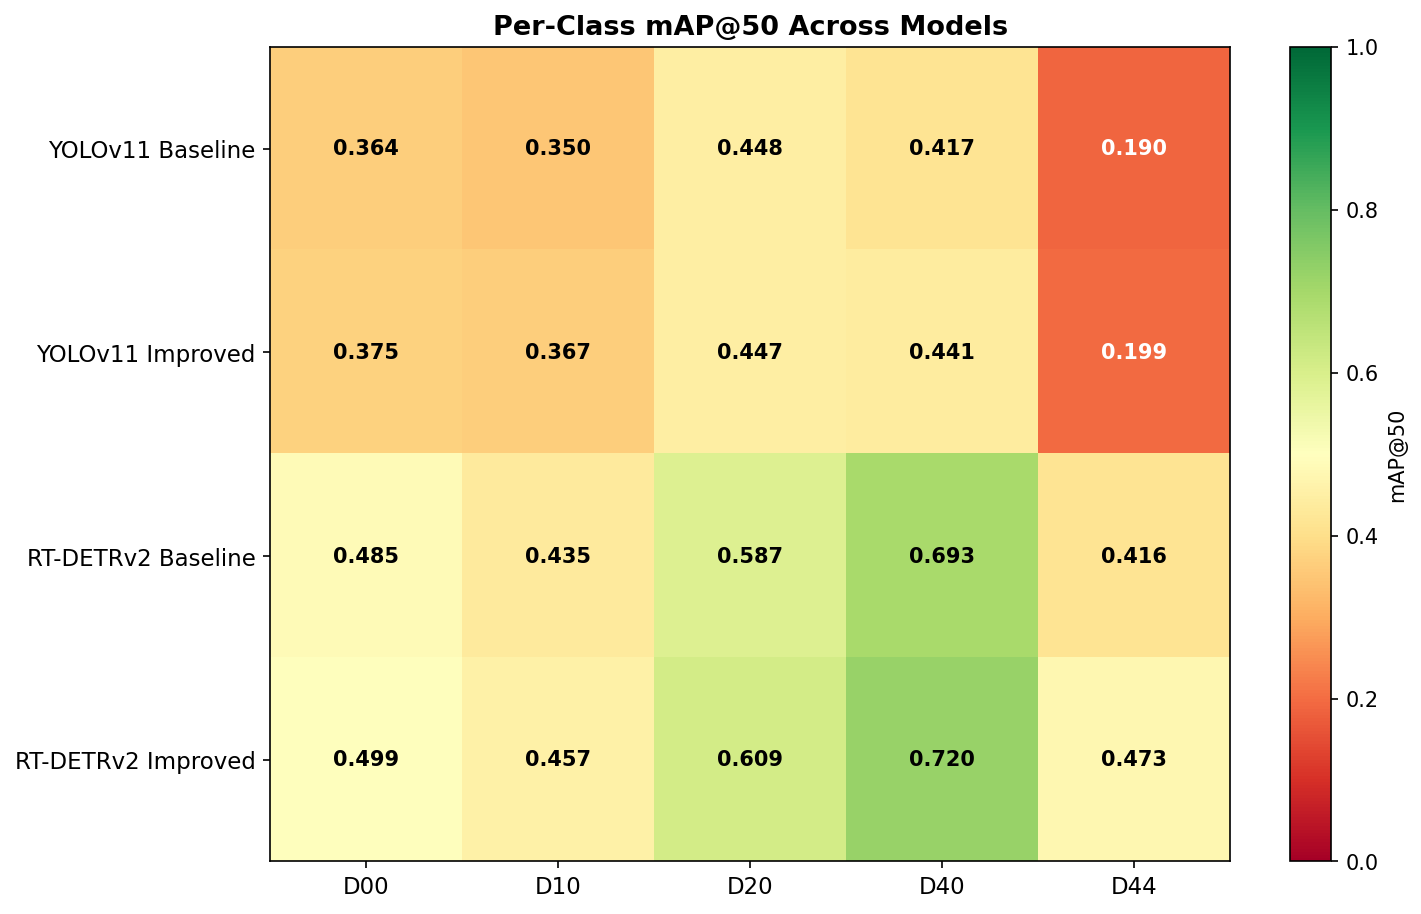


── detection_grid.png ──


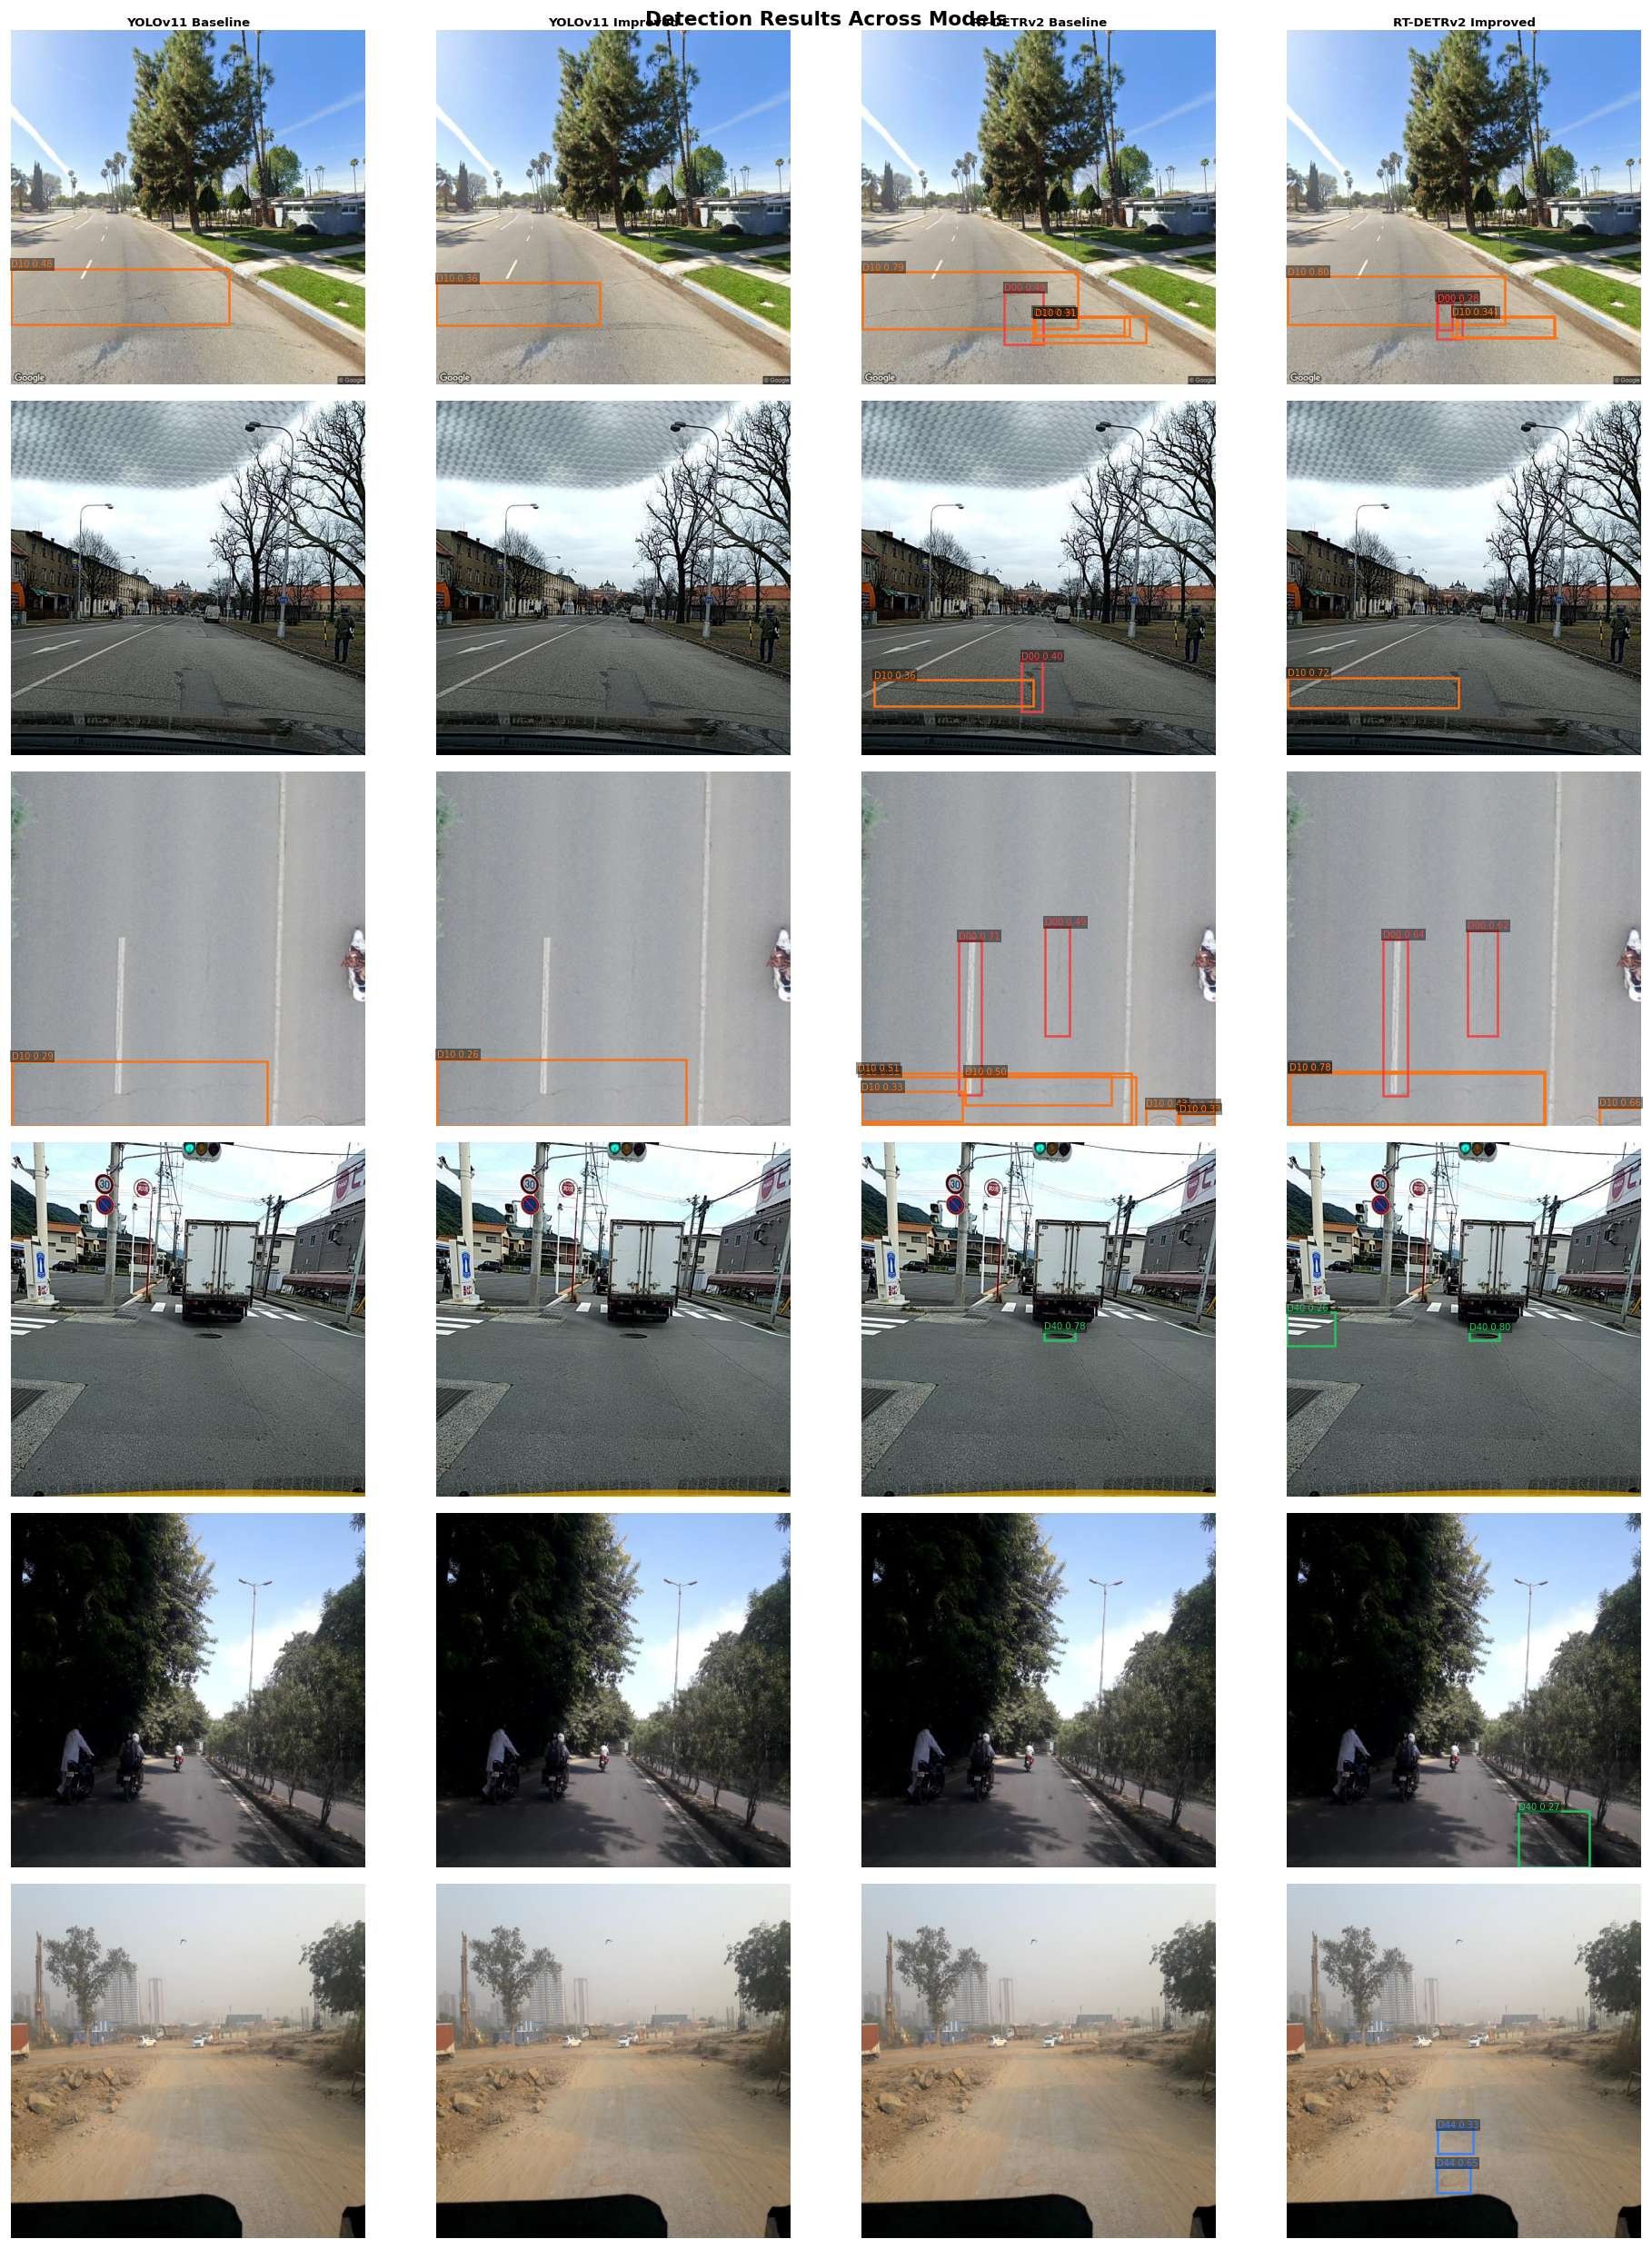

In [44]:
from IPython.display import Image, display
import os

OUTPUT = "/content/road_damage_detection/runs/ablation"

for fname in ["metrics_comparison.png", "loss_curves.png",
              "metric_curves.png", "per_class_mAP.png", "detection_grid.png"]:
    path = os.path.join(OUTPUT, fname)
    if os.path.exists(path):
        print(f"\n── {fname} ──")
        display(Image(path))